#Setup: install packages


In [ ]:
!pip -q install pandas openpyxl Sastrawi unidecode emoji wordcloud matplotlib

import os, pandas as pd
import re, unicodedata, random, string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from unidecode import unidecode
import emoji

# Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Styling matplotlib
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
random.seed(42)
np.random.seed(42)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 30.0 MB/s eta 0:00:00


#Load data

In [ ]:
INPUT_FILE = "/content/data_repo.csv"

assert os.path.exists(INPUT_FILE), f"File tidak ditemukan: {INPUT_FILE}"
print("Loaded:", INPUT_FILE)

# Deteksi tipe file
ext = INPUT_FILE.lower().split(".")[-1]

# Load CSV / Excel
if ext in ("xlsx", "xls"):
    df = pd.read_excel(INPUT_FILE, dtype=str).fillna("")
else:
    df = pd.read_csv(
        INPUT_FILE,
        dtype=str,
        keep_default_na=False,
        engine="python",
        sep=";",              # <-- CSV kamu pakai tanda ; sebagai pemisah kolom!
        on_bad_lines="skip"   # aman
    ).fillna("")

# Pastikan kolom kunci ada
col_map = {c.lower(): c for c in df.columns}

title_col    = col_map.get("title")
abstract_col = col_map.get("abstract")
url_col      = col_map.get("url")

assert title_col is not None,    "Kolom 'title' tidak ditemukan!"
assert abstract_col is not None, "Kolom 'abstract' tidak ditemukan!"
assert url_col is not None,      "Kolom 'url' tidak ditemukan!"

# Susun ulang kolom (url-title-abstract duluan)
other_cols = [c for c in df.columns if c not in (url_col, title_col, abstract_col)]
df = df[[url_col, title_col, abstract_col] + other_cols].copy()
df.columns = ["url", "title", "abstract"] + other_cols

print(f"Rows: {len(df)}")
print("Columns:", list(df.columns))

df.head(10)


Loaded: /content/data_repo.csv
Rows: 15326
Columns: ['url', 'title', 'abstract']


,url,title,abstract
0,https://repository.upnjatim.ac.id/1000/,PENERAPAN METODE CLARKE AND WRIGHT SAVING HEUR...,Koperasi Kareb Bojonegoro bagian distributor m...
1,https://repository.upnjatim.ac.id/1001/,OPINION SHOPPING SEBAGAI PEMODERASI PENGARUH F...,Penelitian ini bertujuan untuk membuktikan opi...
2,https://repository.upnjatim.ac.id/10014/,PREDIKSI PENYAKIT JANTUNG MENGGUNAKAN ALGORITM...,Penyakit jantung merupakan suatu gangguan pada...
3,https://repository.upnjatim.ac.id/10015/,IDENTIFIKASI TANDA TANGAN DENGAN METODE CONVOL...,Setiap manusia pasti memiliki tanda tangan yan...
4,https://repository.upnjatim.ac.id/10016/,IDENTIFIKASI MATA UANG LOGAM MENGGUNAKAN SEGME...,Uang adalah alat pembayaran yang digunakan seh...
5,https://repository.upnjatim.ac.id/10019/,PEMBUATAN BIOETANOL DARI LIMBAH CAIR TEPUNG TE...,Kebutuhan tepung terigu akan cukup besar di In...
6,https://repository.upnjatim.ac.id/1002/,WANPRESTASI DEBITUR DALAM PERJANJIAN KREDIT US...,Penelitian ini bertujuan untuk memahami bagaim...
7,https://repository.upnjatim.ac.id/1003/,PERANCANGAN MODEL TRANSPORTASI SUBWAY DENGAN P...,Kemacetan lalu lintas sekarang dianggap sebaga...
8,https://repository.upnjatim.ac.id/1004/,SISTEM PENILAIAN USULAN RISET DAN PENGABDIAN K...,Universitas berfungsi untuk memfasilitasi sert...
9,https://repository.upnjatim.ac.id/10040/,“PEMBUATAN BIOPLASTIK BERBAHAN DASAR PATI BIJI...,Plastik merupakan bahan yang sulit terurai bah...


#Helper: fungsi pembersih, tokenizer, stopwords, stemmer


In [ ]:
# CUSTOM STOPWORDS
CUSTOM_STOPWORDS = {
    "skripsi","thesis","undergraduate","universitas","veteran","jawa","timur",
    "departement","department","faculty","fakultas","jurusan","program","studi",
    "penelitian","peneliti","abstrak","abstract","katakunci","kunci",
    "upn","upnjatim","surabaya"
}

# Sastrawi stemming (opsional)
stemmer = StemmerFactory().create_stemmer()

# Regex & utils
URL_RE   = re.compile(r"https?://\S+|www\.\S+", re.I)
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", re.I)
# Token: pertahankan istilah teknis (tio2, peg-400, xrd)
TOKEN_RE = re.compile(r"[a-z0-9]+(?:[a-z0-9\-_/]*[a-z0-9])?", re.I)

def normalize_text(s: str) -> str:
    if not isinstance(s, str):
        s = "" if pd.isna(s) else str(s)
    s = unicodedata.normalize("NFKC", s)
    s = URL_RE.sub(" ", s)
    s = EMAIL_RE.sub(" ", s)
    s = emoji.replace_emoji(s, replace=" ")
    s = unidecode(s)
    s = s.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    s = s.replace("“"," ").replace("”"," ").replace("‘"," ").replace("’"," ").replace('"'," ").replace("'"," ")
    s = re.sub(r"\s{2,}", " ", s).strip()
    return s

def case_fold(s: str) -> str:
    return s.lower()

def tokenize(s: str):
    if not s: return []
    return [t for t in TOKEN_RE.findall(s)]

def remove_stopwords_with(tokens, stopset):
    return [t for t in tokens if (t not in stopset and len(t) >= 2)]

def stem_tokens(tokens):
    if not tokens: return tokens
    text = " ".join(tokens)
    stemmed = stemmer.stem(text)
    return [t for t in stemmed.split() if t]

def preview_df(df_, cols, n=5, title=None):
    sample = df_[cols].head(n).copy()
    if title:
        print("\n" + "="*len(title) + f"\n{title}\n" + "="*len(title))
    pd.set_option("display.max_colwidth", 200)
    display(sample)


#Baca file CSV/XLSX dan pilih kolom
### Otomatis deteksi CSV/XLSX, kolom wajib: url, title, abstract (type/error opsional)

In [ ]:
# 1) Baca file (auto deteksi csv/xlsx)
ext = INPUT_FILE.lower().split(".")[-1]
if ext in ("xlsx","xls"):
    df = pd.read_excel(INPUT_FILE, dtype=str).fillna("")
else:
    df = pd.read_csv(INPUT_FILE, dtype=str, keep_default_na=False).fillna("")

# 2) Standarkan nama & urutan kolom (url, title, abstract di depan)
col_map = {c.lower(): c for c in df.columns}
title_col    = col_map.get("title", "title")
abstract_col = col_map.get("abstract", "abstract")
url_col      = col_map.get("url", "url")
assert title_col in df.columns and abstract_col in df.columns, "Kolom 'title' dan 'abstract' wajib ada."

df = df[[url_col, title_col, abstract_col] + [c for c in df.columns if c not in (url_col,title_col,abstract_col)]].copy()
df.columns = ["url","title","abstract"] + [c for c in df.columns if c not in ("url","title","abstract")]

print(f"Rows: {len(df)}")
print("Columns:", list(df.columns))

# (opsional) tampilkan tabel lebih nyaman
pd.set_option("display.max_colwidth", 400)
# sample[["url","title","abstract"]]

ParserError: Error tokenizing data. C error: Expected 8 fields in line 3, saw 15


## 1) Normalisasi & Case Folding


Title: raw vs normalized


,title,title_norm
0,PENERAPAN METODE CLARKE AND WRIGHT SAVING HEURISTIC DALAM MENENTUKAN RUTE PENDISTRIBUSIAN PRODUK DI BAGIAN DISTRIBUTOR KOPERASI KAREB BOJONEGORO,penerapan metode clarke and wright saving heuristic dalam menentukan rute pendistribusian produk di bagian distributor koperasi kareb bojonegoro
1,"OPINION SHOPPING SEBAGAI PEMODERASI PENGARUH FINANCIAL DISTRESS, AUDIT CLIENT TENURE DAN REPUTASI AUDITOR TERHADAP OPINI AUDIT GOING CONCERN","opinion shopping sebagai pemoderasi pengaruh financial distress, audit client tenure dan reputasi auditor terhadap opini audit going concern"
2,PREDIKSI PENYAKIT JANTUNG MENGGUNAKAN ALGORITMALEARNING VECTOR QUANTIZATION DAN PARTICLE SWARM OPTIMIZATION,prediksi penyakit jantung menggunakan algoritmalearning vector quantization dan particle swarm optimization
3,IDENTIFIKASI TANDA TANGAN DENGAN METODE CONVOLUTIONAL NEURAL NETWORK,identifikasi tanda tangan dengan metode convolutional neural network
4,IDENTIFIKASI MATA UANG LOGAM MENGGUNAKAN SEGMENTASI OTSU THRESHOLDING DENGAN OPERASI MORFOLOGI,identifikasi mata uang logam menggunakan segmentasi otsu thresholding dengan operasi morfologi



Abstract: raw vs normalized


,abstract,abstract_norm
0,Koperasi Kareb Bojonegoro bagian distributor merupakan salah satu bagian dari unit kerja pertokoan. Koperasi Kareb Bojonegoro bagian distributor melayani pendistribusian produk seperti bahan makan...,koperasi kareb bojonegoro bagian distributor merupakan salah satu bagian dari unit kerja pertokoan. koperasi kareb bojonegoro bagian distributor melayani pendistribusian produk seperti bahan makan...
1,"Penelitian ini bertujuan untuk membuktikan opinion shopping sebagai pengaruh moderasi dari financial distress, audit client tenure dan reputasi auditor terhadap opini audit going concern. Peneliti...","penelitian ini bertujuan untuk membuktikan opinion shopping sebagai pengaruh moderasi dari financial distress, audit client tenure dan reputasi auditor terhadap opini audit going concern. peneliti..."
2,Penyakit jantung merupakan suatu gangguan pada sistem pembuluh darah sehingga menyebabkan kinerja jantung tidak dapat bekerja secara normal. Organisasi Kesehatan Dunia (WHO) memperkirakan sekitar ...,penyakit jantung merupakan suatu gangguan pada sistem pembuluh darah sehingga menyebabkan kinerja jantung tidak dapat bekerja secara normal. organisasi kesehatan dunia (who) memperkirakan sekitar ...


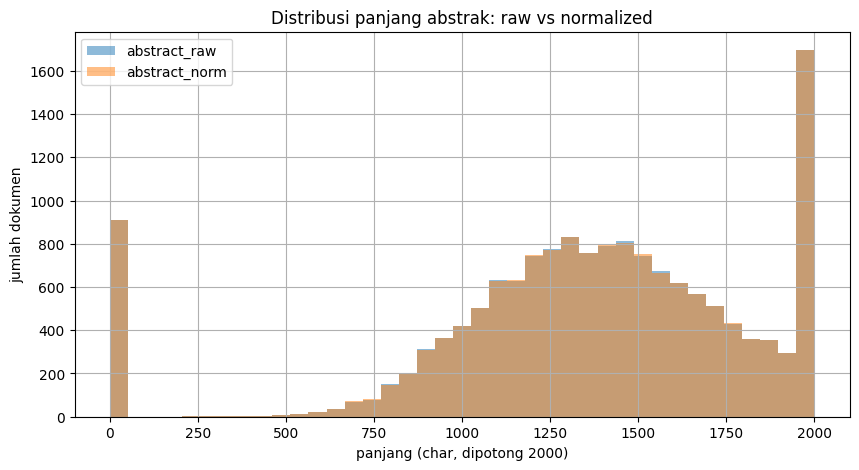

In [ ]:
df["title_norm"]    = df["title"].apply(normalize_text).apply(case_fold)
df["abstract_norm"] = df["abstract"].apply(normalize_text).apply(case_fold)

preview_df(df, ["title","title_norm"], n=5, title="Title: raw vs normalized")
preview_df(df, ["abstract","abstract_norm"], n=3, title="Abstract: raw vs normalized")

# Visual panjang
def plot_len_hist(series_before, series_after, label_before, label_after, title):
    plt.figure()
    a = series_before.str.len().clip(upper=2000)
    b = series_after.str.len().clip(upper=2000)
    bins = np.linspace(0, max(a.max(), b.max()), 40)
    plt.hist(a, bins=bins, alpha=0.5, label=label_before)
    plt.hist(b, bins=bins, alpha=0.5, label=label_after)
    plt.title(title); plt.xlabel("panjang (char, dipotong 2000)"); plt.ylabel("jumlah dokumen"); plt.legend()
    plt.show()

plot_len_hist(df["abstract"], df["abstract_norm"], "abstract_raw", "abstract_norm",
              "Distribusi panjang abstrak: raw vs normalized")


## 2) Tokenisasi


Title: tokens


,title_norm,title_tok
0,penerapan metode clarke and wright saving heuristic dalam menentukan rute pendistribusian produk di bagian distributor koperasi kareb bojonegoro,"[penerapan, metode, clarke, and, wright, saving, heuristic, dalam, menentukan, rute, pendistribusian, produk, di, bagian, distributor, koperasi, kareb, bojonegoro]"
1,"opinion shopping sebagai pemoderasi pengaruh financial distress, audit client tenure dan reputasi auditor terhadap opini audit going concern","[opinion, shopping, sebagai, pemoderasi, pengaruh, financial, distress, audit, client, tenure, dan, reputasi, auditor, terhadap, opini, audit, going, concern]"
2,prediksi penyakit jantung menggunakan algoritmalearning vector quantization dan particle swarm optimization,"[prediksi, penyakit, jantung, menggunakan, algoritmalearning, vector, quantization, dan, particle, swarm, optimization]"
3,identifikasi tanda tangan dengan metode convolutional neural network,"[identifikasi, tanda, tangan, dengan, metode, convolutional, neural, network]"
4,identifikasi mata uang logam menggunakan segmentasi otsu thresholding dengan operasi morfologi,"[identifikasi, mata, uang, logam, menggunakan, segmentasi, otsu, thresholding, dengan, operasi, morfologi]"



Abstract: tokens


,abstract_norm,abstract_tok
0,koperasi kareb bojonegoro bagian distributor merupakan salah satu bagian dari unit kerja pertokoan. koperasi kareb bojonegoro bagian distributor melayani pendistribusian produk seperti bahan makan...,"[koperasi, kareb, bojonegoro, bagian, distributor, merupakan, salah, satu, bagian, dari, unit, kerja, pertokoan, koperasi, kareb, bojonegoro, bagian, distributor, melayani, pendistribusian, produk..."
1,"penelitian ini bertujuan untuk membuktikan opinion shopping sebagai pengaruh moderasi dari financial distress, audit client tenure dan reputasi auditor terhadap opini audit going concern. peneliti...","[penelitian, ini, bertujuan, untuk, membuktikan, opinion, shopping, sebagai, pengaruh, moderasi, dari, financial, distress, audit, client, tenure, dan, reputasi, auditor, terhadap, opini, audit, g..."
2,penyakit jantung merupakan suatu gangguan pada sistem pembuluh darah sehingga menyebabkan kinerja jantung tidak dapat bekerja secara normal. organisasi kesehatan dunia (who) memperkirakan sekitar ...,"[penyakit, jantung, merupakan, suatu, gangguan, pada, sistem, pembuluh, darah, sehingga, menyebabkan, kinerja, jantung, tidak, dapat, bekerja, secara, normal, organisasi, kesehatan, dunia, who, me..."


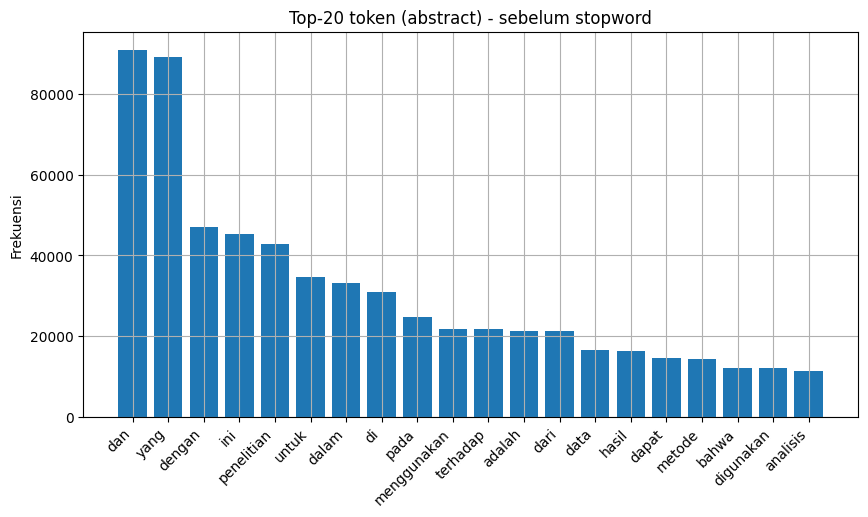

In [ ]:
df["title_tok"]    = df["title_norm"].apply(tokenize)
df["abstract_tok"] = df["abstract_norm"].apply(tokenize)

preview_df(df, ["title_norm","title_tok"], n=5, title="Title: tokens")
preview_df(df, ["abstract_norm","abstract_tok"], n=3, title="Abstract: tokens")

# Top token sebelum stopword
all_tokens = [t for tokens in df["abstract_tok"] for t in tokens]
cnt = Counter(all_tokens)
top = cnt.most_common(20)
plt.figure(); plt.bar([w for w,_ in top], [c for _,c in top])
plt.title("Top-20 token (abstract) - sebelum stopword"); plt.xticks(rotation=45, ha="right"); plt.ylabel("Frekuensi"); plt.show()


## 3) Stopword Removal


Title (BM25): sebelum vs sesudah stopword


,title_tok,title_nostop_bm25
0,"[penerapan, metode, clarke, and, wright, saving, heuristic, dalam, menentukan, rute, pendistribusian, produk, di, bagian, distributor, koperasi, kareb, bojonegoro]","[penerapan, metode, clarke, and, wright, saving, heuristic, dalam, menentukan, rute, pendistribusian, produk, di, bagian, distributor, koperasi, kareb, bojonegoro]"
1,"[opinion, shopping, sebagai, pemoderasi, pengaruh, financial, distress, audit, client, tenure, dan, reputasi, auditor, terhadap, opini, audit, going, concern]","[opinion, shopping, sebagai, pemoderasi, pengaruh, financial, distress, audit, client, tenure, dan, reputasi, auditor, terhadap, opini, audit, going, concern]"
2,"[prediksi, penyakit, jantung, menggunakan, algoritmalearning, vector, quantization, dan, particle, swarm, optimization]","[prediksi, penyakit, jantung, menggunakan, algoritmalearning, vector, quantization, dan, particle, swarm, optimization]"
3,"[identifikasi, tanda, tangan, dengan, metode, convolutional, neural, network]","[identifikasi, tanda, tangan, dengan, metode, convolutional, neural, network]"
4,"[identifikasi, mata, uang, logam, menggunakan, segmentasi, otsu, thresholding, dengan, operasi, morfologi]","[identifikasi, mata, uang, logam, menggunakan, segmentasi, otsu, thresholding, dengan, operasi, morfologi]"



Abstract (BM25): sebelum vs sesudah stopword


,abstract_tok,abstract_nostop_bm25
0,"[koperasi, kareb, bojonegoro, bagian, distributor, merupakan, salah, satu, bagian, dari, unit, kerja, pertokoan, koperasi, kareb, bojonegoro, bagian, distributor, melayani, pendistribusian, produk...","[koperasi, kareb, bojonegoro, bagian, distributor, merupakan, salah, satu, bagian, dari, unit, kerja, pertokoan, koperasi, kareb, bojonegoro, bagian, distributor, melayani, pendistribusian, produk..."
1,"[penelitian, ini, bertujuan, untuk, membuktikan, opinion, shopping, sebagai, pengaruh, moderasi, dari, financial, distress, audit, client, tenure, dan, reputasi, auditor, terhadap, opini, audit, g...","[ini, bertujuan, untuk, membuktikan, opinion, shopping, sebagai, pengaruh, moderasi, dari, financial, distress, audit, client, tenure, dan, reputasi, auditor, terhadap, opini, audit, going, concer..."
2,"[penyakit, jantung, merupakan, suatu, gangguan, pada, sistem, pembuluh, darah, sehingga, menyebabkan, kinerja, jantung, tidak, dapat, bekerja, secara, normal, organisasi, kesehatan, dunia, who, me...","[penyakit, jantung, merupakan, suatu, gangguan, pada, sistem, pembuluh, darah, sehingga, menyebabkan, kinerja, jantung, tidak, dapat, bekerja, secara, normal, organisasi, kesehatan, dunia, who, me..."


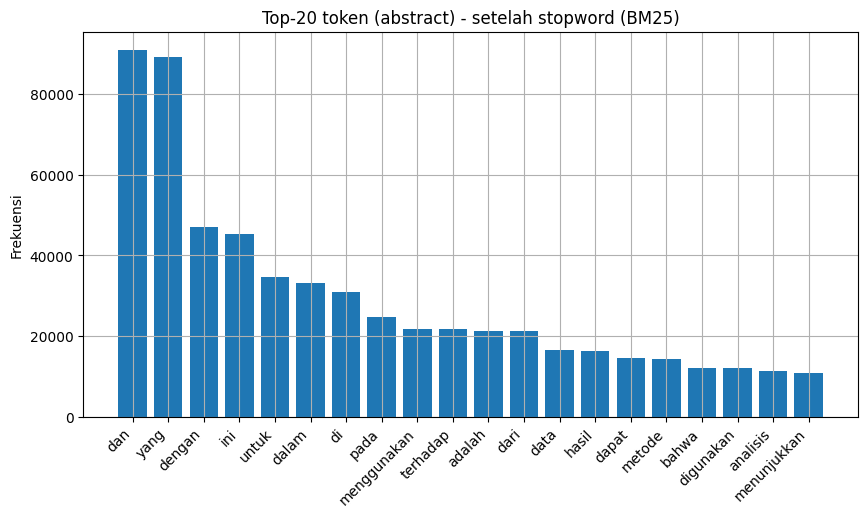

Total CUSTOM_STOPWORDS: 23


In [ ]:
# BM25 / lexical
df["title_nostop_bm25"]    = df["title_tok"].apply(lambda xs: remove_stopwords_with(xs, CUSTOM_STOPWORDS))
df["abstract_nostop_bm25"] = df["abstract_tok"].apply(lambda xs: remove_stopwords_with(xs, CUSTOM_STOPWORDS))

# fastText QE
df["title_nostop_ft"]    = df["title_tok"].apply(lambda xs: remove_stopwords_with(xs, CUSTOM_STOPWORDS))
df["abstract_nostop_ft"] = df["abstract_tok"].apply(lambda xs: remove_stopwords_with(xs, CUSTOM_STOPWORDS))

preview_df(df, ["title_tok","title_nostop_bm25"], n=5, title="Title (BM25): sebelum vs sesudah stopword")
preview_df(df, ["abstract_tok","abstract_nostop_bm25"], n=3, title="Abstract (BM25): sebelum vs sesudah stopword")

# Visual: Top token setelah stopword (BM25)
all_tokens_ns = [t for tokens in df["abstract_nostop_bm25"] for t in tokens]
cnt_ns = Counter(all_tokens_ns); top_ns = cnt_ns.most_common(20)
plt.figure(); plt.bar([w for w,_ in top_ns], [c for _,c in top_ns])
plt.title("Top-20 token (abstract) - setelah stopword (BM25)")
plt.xticks(rotation=45, ha="right"); plt.ylabel("Frekuensi"); plt.show()

print("Total CUSTOM_STOPWORDS:", len(CUSTOM_STOPWORDS))

In [ ]:
# Tampilkan ringkasan kamus stopword yang dipakai
# Sastrawi default stopwords
factory = StopWordRemoverFactory()
ID_STOPWORDS = set(factory.get_stop_words())

# Combine with custom stopwords
STOPWORDS = ID_STOPWORDS.union(CUSTOM_STOPWORDS)

print("Jumlah stopword Sastrawi:", len(ID_STOPWORDS))
print("Jumlah custom stopwords :", len(CUSTOM_STOPWORDS))
print("Total STOPWORDS dipakai :", len(STOPWORDS))

# Lihat sebagian isinya (urut a0lfabet)
preview = sorted(list(STOPWORDS))[:100]  # tampilkan 100 pertama
print("\nContoh 100 stopword yang dipakai:\n", preview[:100])

Jumlah stopword Sastrawi: 123
Jumlah custom stopwords : 23
Total STOPWORDS dipakai : 146

Contoh 100 stopword yang dipakai:
 ['abstract', 'abstrak', 'ada', 'adalah', 'agak', 'agar', 'akan', 'amat', 'anda', 'antara', 'anu', 'apakah', 'apalagi', 'atau', 'bagaimanapun', 'bagi', 'bahwa', 'begitu', 'belum', 'bisa', 'boleh', 'dahulu', 'dalam', 'dan', 'dapat', 'dari', 'daripada', 'demi', 'demikian', 'dengan', 'departement', 'department', 'di', 'dia', 'dimana', 'dll', 'dsb', 'dst', 'dua', 'dulunya', 'faculty', 'fakultas', 'guna', 'hal', 'hanya', 'harus', 'ia', 'ingin', 'ini', 'itu', 'itulah', 'jawa', 'jika', 'juga', 'jurusan', 'kah', 'kami', 'karena', 'katakunci', 'ke', 'kecuali', 'kemana', 'kembali', 'kenapa', 'kepada', 'ketika', 'kita', 'kunci', 'lagi', 'lain', 'maka', 'mari', 'masih', 'melainkan', 'mengapa', 'menurut', 'mereka', 'namun', 'nanti', 'nggak', 'oh', 'ok', 'oleh', 'pada', 'para', 'pasti', 'peneliti', 'penelitian', 'program', 'pula', 'pun', 'saat', 'saja', 'sambil', 'sampai', 'say

In [ ]:
# Kumpulkan semua token yang TERHAPUS oleh stopword removal (dari kolom abstract)
removed_tokens = []
for before, after in zip(df["abstract_tok"], df["abstract_nostop_bm25"]):
    # token yang ada di before tapi hilang di after
    # gunakan multiset difference (berbasis frekuensi)
    cnt_before = Counter(before)
    cnt_after  = Counter(after)
    diff = cnt_before - cnt_after
    # simpan hanya token yang memang termasuk STOPWORDS (bisa juga ada token non-stop yang hilang karena filter panjang)
    for tok, freq in diff.items():
        if tok in STOPWORDS:
            removed_tokens.extend([tok]*freq)

removed_freq = Counter(removed_tokens).most_common(30)
print("Top-30 stopword yang paling sering terhapus (dari ABSTRACT):")
for w,c in removed_freq:
    print(f"{w:15s} {c}")

Top-30 stopword yang paling sering terhapus (dari ABSTRACT):
penelitian      42770
kunci           7860
surabaya        7204
jawa            3730
timur           3427
program         2794
studi           2375
peneliti        1058
veteran         846
upn             605
universitas     506
abstrak         466
skripsi         339
fakultas        324
jurusan         84
department      13
departement     6
upnjatim        5
katakunci       4


## 4) Stemming (Sastrawi)

In [ ]:
from tqdm import tqdm
tqdm.pandas()

USE_STEMMING_BM25 = False

if USE_STEMMING_BM25:
    df["title_stem_bm25_tok"]    = df["title_nostop_bm25"].progress_apply(stem_tokens)
    df["abstract_stem_bm25_tok"] = df["abstract_nostop_bm25"].progress_apply(stem_tokens)
    df["title_stem_bm25"]    = df["title_stem_bm25_tok"].progress_apply(lambda xs: " ".join(xs))
    df["abstract_stem_bm25"] = df["abstract_stem_bm25_tok"].progress_apply(lambda xs: " ".join(xs))
    preview_df(df, ["title_nostop_bm25","title_stem_bm25_tok","title_stem_bm25"], n=3,
               title="Title: setelah stemming (BM25)")
    preview_df(df, ["abstract_nostop_bm25","abstract_stem_bm25_tok","abstract_stem_bm25"], n=3,
               title="Abstract: setelah stemming (BM25)")


#Simpan hasil akhir (CSV & Parquet)

In [ ]:
# 1) SEMANTIC (IndoBERT): minimal-clean (tanpa stopword/stem)
df["text_semantic"] = (df["title_norm"] + " " + df["abstract_norm"]).str.strip()

# 2) BM25: CUSTOM stopwords, dengan/ tanpa stemming
if USE_STEMMING_BM25:
    df["text_bm25"] = (df["title_stem_bm25"] + " " + df["abstract_stem_bm25"]).str.strip()
else:
    df["text_bm25"] = (df["title_nostop_bm25"].apply(" ".join) + " " +
                       df["abstract_nostop_bm25"].apply(" ".join)).str.strip()

# 3) fastText: CUSTOM stopwords, TANPA stemming
df["text_fasttext"] = (df["title_nostop_ft"].apply(" ".join) + " " +
                       df["abstract_nostop_ft"].apply(" ".join)).str.strip()

preview_df(df, ["url","text_semantic","text_bm25","text_fasttext"], n=3, title="Preview 3 view teks (CUSTOM only)")



Preview 3 view teks (CUSTOM only)


,url,text_semantic,text_bm25,text_fasttext
0,https://repository.upnjatim.ac.id/1000/,penerapan metode clarke and wright saving heuristic dalam menentukan rute pendistribusian produk di bagian distributor koperasi kareb bojonegoro koperasi kareb bojonegoro bagian distributor merupa...,penerapan metode clarke and wright saving heuristic dalam menentukan rute pendistribusian produk di bagian distributor koperasi kareb bojonegoro koperasi kareb bojonegoro bagian distributor merupa...,penerapan metode clarke and wright saving heuristic dalam menentukan rute pendistribusian produk di bagian distributor koperasi kareb bojonegoro koperasi kareb bojonegoro bagian distributor merupa...
1,https://repository.upnjatim.ac.id/1001/,"opinion shopping sebagai pemoderasi pengaruh financial distress, audit client tenure dan reputasi auditor terhadap opini audit going concern penelitian ini bertujuan untuk membuktikan opinion shop...",opinion shopping sebagai pemoderasi pengaruh financial distress audit client tenure dan reputasi auditor terhadap opini audit going concern ini bertujuan untuk membuktikan opinion shopping sebagai...,opinion shopping sebagai pemoderasi pengaruh financial distress audit client tenure dan reputasi auditor terhadap opini audit going concern ini bertujuan untuk membuktikan opinion shopping sebagai...
2,https://repository.upnjatim.ac.id/10014/,prediksi penyakit jantung menggunakan algoritmalearning vector quantization dan particle swarm optimization penyakit jantung merupakan suatu gangguan pada sistem pembuluh darah sehingga menyebabka...,prediksi penyakit jantung menggunakan algoritmalearning vector quantization dan particle swarm optimization penyakit jantung merupakan suatu gangguan pada sistem pembuluh darah sehingga menyebabka...,prediksi penyakit jantung menggunakan algoritmalearning vector quantization dan particle swarm optimization penyakit jantung merupakan suatu gangguan pada sistem pembuluh darah sehingga menyebabka...


In [ ]:
keep_cols = [
    "url","title","abstract",
    "text_semantic",  # IndoBERT embeddings & contextual QE
    "text_bm25",      # BM25 & QE leksikal (CUSTOM stopwords; stemming opsional)
    "text_fasttext"   # fastText QE (CUSTOM stopwords, tanpa stemming)
]
out = df[keep_cols].copy()

out.to_csv("data_repo_preprocessed.csv", index=False, encoding="utf-8-sig")
out.to_parquet("data_repo_preprocessed.parquet", index=False)
print("Saved:")
print("- data_repo_preprocessed.csv")
print("- data_repo_preprocessed.parquet")

# contoh cek cepat
pd.set_option("display.max_colwidth", 180)
display(out.head(5)[["url","title","abstract","text_semantic","text_bm25","text_fasttext"]])


Saved:
- data_repo_preprocessed.csv
- data_repo_preprocessed.parquet


,url,title,abstract,text_semantic,text_bm25,text_fasttext
0,https://repository.upnjatim.ac.id/1000/,PENERAPAN METODE CLARKE AND WRIGHT SAVING HEURISTIC DALAM MENENTUKAN RUTE PENDISTRIBUSIAN PRODUK DI BAGIAN DISTRIBUTOR KOPERASI KAREB BOJONEGORO,Koperasi Kareb Bojonegoro bagian distributor merupakan salah satu bagian dari unit kerja pertokoan. Koperasi Kareb Bojonegoro bagian distributor melayani pendistribusian produk...,penerapan metode clarke and wright saving heuristic dalam menentukan rute pendistribusian produk di bagian distributor koperasi kareb bojonegoro koperasi kareb bojonegoro bagia...,penerapan metode clarke and wright saving heuristic dalam menentukan rute pendistribusian produk di bagian distributor koperasi kareb bojonegoro koperasi kareb bojonegoro bagia...,penerapan metode clarke and wright saving heuristic dalam menentukan rute pendistribusian produk di bagian distributor koperasi kareb bojonegoro koperasi kareb bojonegoro bagia...
1,https://repository.upnjatim.ac.id/1001/,"OPINION SHOPPING SEBAGAI PEMODERASI PENGARUH FINANCIAL DISTRESS, AUDIT CLIENT TENURE DAN REPUTASI AUDITOR TERHADAP OPINI AUDIT GOING CONCERN","Penelitian ini bertujuan untuk membuktikan opinion shopping sebagai pengaruh moderasi dari financial distress, audit client tenure dan reputasi auditor terhadap opini audit goi...","opinion shopping sebagai pemoderasi pengaruh financial distress, audit client tenure dan reputasi auditor terhadap opini audit going concern penelitian ini bertujuan untuk memb...",opinion shopping sebagai pemoderasi pengaruh financial distress audit client tenure dan reputasi auditor terhadap opini audit going concern ini bertujuan untuk membuktikan opin...,opinion shopping sebagai pemoderasi pengaruh financial distress audit client tenure dan reputasi auditor terhadap opini audit going concern ini bertujuan untuk membuktikan opin...
2,https://repository.upnjatim.ac.id/10014/,PREDIKSI PENYAKIT JANTUNG MENGGUNAKAN ALGORITMALEARNING VECTOR QUANTIZATION DAN PARTICLE SWARM OPTIMIZATION,Penyakit jantung merupakan suatu gangguan pada sistem pembuluh darah sehingga menyebabkan kinerja jantung tidak dapat bekerja secara normal. Organisasi Kesehatan Dunia (WHO) me...,prediksi penyakit jantung menggunakan algoritmalearning vector quantization dan particle swarm optimization penyakit jantung merupakan suatu gangguan pada sistem pembuluh darah...,prediksi penyakit jantung menggunakan algoritmalearning vector quantization dan particle swarm optimization penyakit jantung merupakan suatu gangguan pada sistem pembuluh darah...,prediksi penyakit jantung menggunakan algoritmalearning vector quantization dan particle swarm optimization penyakit jantung merupakan suatu gangguan pada sistem pembuluh darah...
3,https://repository.upnjatim.ac.id/10015/,IDENTIFIKASI TANDA TANGAN DENGAN METODE CONVOLUTIONAL NEURAL NETWORK,Setiap manusia pasti memiliki tanda tangan yang berbeda – beda. Tanda tangan biasanya digunakan untuk mengidentifikasi seseorang. Tanda tangan manusia sebenarnya dapat dengan m...,identifikasi tanda tangan dengan metode convolutional neural network setiap manusia pasti memiliki tanda tangan yang berbeda - beda. tanda tangan biasanya digunakan untuk mengi...,identifikasi tanda tangan dengan metode convolutional neural network setiap manusia pasti memiliki tanda tangan yang berbeda beda tanda tangan biasanya digunakan untuk mengiden...,identifikasi tanda tangan dengan metode convolutional neural network setiap manusia pasti memiliki tanda tangan yang berbeda beda tanda tangan biasanya digunakan untuk mengiden...
4,https://repository.upnjatim.ac.id/10016/,IDENTIFIKASI MATA UANG LOGAM MENGGUNAKAN SEGMENTASI OTSU THRESHOLDING DENGAN OPERASI MORFOLOGI,Uang adalah alat pembayaran yang digunakan sehari-hari. Penyayang tunanetra juga menggunakan uang sebagai alat transaksi pada kehidupan sehari-hari. Keterbatasan penyandang tun...,identifikasi mata uang logam menggunakan segmentasi otsu thresholding dengan operasi morfologi uang adala

In [ ]:
import pandas as pd
df = pd.read_csv("data_repo_preprocessed.csv", dtype=str, keep_default_na=False)

print("Rows:", len(df))
print("Columns:", list(df.columns))

# Kolom wajib tidak kosong
for col in ["text_semantic","text_bm25","text_fasttext"]:
    empty = (df[col].str.strip()=="").sum()
    print(f"{col}: empty={empty}")

# Distribusi panjang
for col in ["text_semantic","text_bm25","text_fasttext"]:
    lens = df[col].str.len()
    print(f"{col}: mean={lens.mean():.1f}, median={lens.median():.0f}, min={lens.min()}, max={lens.max()}")


Rows: 15326
Columns: ['url', 'title', 'abstract', 'text_semantic', 'text_bm25', 'text_fasttext']
text_semantic: empty=0
text_bm25: empty=0
text_fasttext: empty=0
text_semantic: mean=1509.4, median=1520, min=12, max=7197
text_bm25: mean=1425.6, median=1435, min=4, max=6865
text_fasttext: mean=1425.6, median=1435, min=4, max=6865
